# Properties of the Derivative — The Product Rule

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **product rule**
(Week 1 — Derivatives and Optimization).

This notebook explains:

- the rule: if $f = g\cdot h$, then $f' = g'h + g h'$ (**not** $g'h'$!)
- the **"hammer"** mnemonic (differentiate one factor at a time)
- the **house-area** derivation ($\Delta f = \Delta g\,h + g\,\Delta h + \Delta g\,\Delta h$)
- why the tiny corner term vanishes in the limit, with SymPy checks and a diagram

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Properties of the Derivative — The Sum Rule*.

## 1. The rule

If a function is the **product** of two functions, the derivative is **not** the product of
the derivatives. Instead:

$$
f(x) = g(x)\,h(x) \quad\Longrightarrow\quad f'(x) = g'(x)\,h(x) + g(x)\,h'(x).
$$

### The "hammer" mnemonic

Think of differentiating as "hitting a function with a hammer." To differentiate $g\cdot h$
you hit **one factor at a time** and add the results:

- hit $g$, leave $h$: $\;g'h$
- hit $h$, leave $g$: $\;g h'$

$$
f' = g'h + g h'.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x')
g = sp.Function('g'); h = sp.Function('h')
print("d/dx [g(x) h(x)] =", sp.diff(g(x)*h(x), x))

# warning: the product of derivatives is NOT the derivative of the product
gg, hh = x**2, sp.sin(x)
print("\n(g·h)'      =", sp.diff(gg*hh, x))
print("g'·h'       =", sp.diff(gg, x)*sp.diff(hh, x), "  <- different!")

d/dx [g(x) h(x)] = g(x)*Derivative(h(x), x) + h(x)*Derivative(g(x), x)

(g·h)'      = x**2*cos(x) + 2*x*sin(x)
g'·h'       = 2*x*cos(x)   <- different!


## 2. The house-area derivation

Imagine **building a house** with two crews: one builds the **side wall** of length
$g(t)$, the other the **front wall** of length $h(t)$, both growing over time. The **area**
of the house is

$$
f(t) = g(t)\,h(t).
$$

We want the rate of change of the area, $f'(t)$, knowing $g'$ and $h'$.

Over a small time $\Delta t$, the side grows by $\Delta g$ and the front by $\Delta h$. The
new area is built from four pieces:

$$
\underbrace{g\,h}_{\text{original}} \;+\; \underbrace{g\,\Delta h}_{\text{strip}}
\;+\; \underbrace{\Delta g\,h}_{\text{strip}} \;+\; \underbrace{\Delta g\,\Delta h}_{\text{tiny corner}}.
$$

So the **change** in area is

$$
\Delta f = \Delta g\,h + g\,\Delta h + \Delta g\,\Delta h .
$$

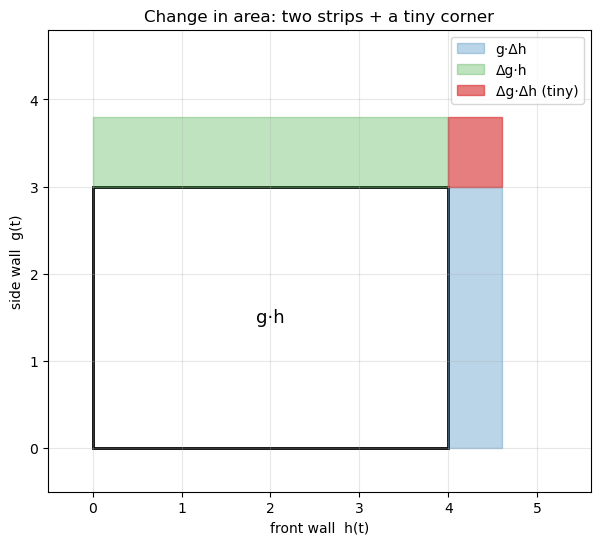

In [2]:
# the four-rectangle picture
g0, h0, dg, dh = 3.0, 4.0, 0.8, 0.6
fig, ax = plt.subplots(figsize=(7, 6))
ax.add_patch(plt.Rectangle((0, 0), h0, g0, fill=False, lw=2))
ax.add_patch(plt.Rectangle((h0, 0), dh, g0, alpha=0.3, color="tab:blue", label="g·Δh"))
ax.add_patch(plt.Rectangle((0, g0), h0, dg, alpha=0.3, color="tab:green", label="Δg·h"))
ax.add_patch(plt.Rectangle((h0, g0), dh, dg, alpha=0.6, color="tab:red", label="Δg·Δh (tiny)"))
ax.text(h0/2, g0/2, "g·h", ha="center", va="center", fontsize=13)
ax.set_xlim(-0.5, h0+dh+1); ax.set_ylim(-0.5, g0+dg+1)
ax.set_xlabel("front wall  h(t)"); ax.set_ylabel("side wall  g(t)")
ax.set_title("Change in area: two strips + a tiny corner")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
plt.show()

## 3. Taking the limit

Divide $\Delta f$ by $\Delta t$:

$$
\frac{\Delta f}{\Delta t}
= \frac{\Delta g}{\Delta t}\,h + g\,\frac{\Delta h}{\Delta t} + \frac{\Delta g\,\Delta h}{\Delta t}.
$$

As $\Delta t \to 0$:

- $\dfrac{\Delta g}{\Delta t} \to g'$ and $\dfrac{\Delta h}{\Delta t} \to h'$,
- the last term $\dfrac{\Delta g\,\Delta h}{\Delta t}$ → **0** (it is "too tiny to care" —
  a product of two vanishing changes).

This leaves the **product rule**:

$$
\boxed{\;f'(t) = g'(t)\,h(t) + g(t)\,h'(t).\;}
$$

In [3]:
# symbolic confirmation of the rule on examples
for gg, hh in [(x**2, sp.sin(x)), (sp.exp(x), x**3), (x, sp.log(x))]:
    lhs = sp.diff(gg*hh, x)
    rhs = sp.diff(gg, x)*hh + gg*sp.diff(hh, x)
    print(f"f = ({gg})({hh}):  (g·h)' = {sp.simplify(lhs)} ; g'h+gh' matches? {sp.simplify(lhs-rhs)==0}")

f = (x**2)(sin(x)):  (g·h)' = x*(x*cos(x) + 2*sin(x)) ; g'h+gh' matches? True
f = (exp(x))(x**3):  (g·h)' = x**2*(x + 3)*exp(x) ; g'h+gh' matches? True
f = (x)(log(x)):  (g·h)' = log(x) + 1 ; g'h+gh' matches? True


### Numerical check

In [4]:
def g_(x): return x**2
def h_(x): return np.sin(x)
def f_(x): return g_(x)*h_(x)

def numder(fn, x, eps=1e-6): return (fn(x+eps)-fn(x-eps))/(2*eps)

x0 = 1.3
numeric = numder(f_, x0)
rule = numder(g_, x0)*h_(x0) + g_(x0)*numder(h_, x0)
print(f"numeric (g·h)' at {x0}: {numeric:.6f}")
print(f"g'h + gh'      at {x0}: {rule:.6f}")

numeric (g·h)' at 1.3: 2.957324
g'h + gh'      at 1.3: 2.957324


## 4. Exercises

### Basic
1. State the product rule. Is $(gh)' = g'h'$?
2. Differentiate $f(x) = x^2 \sin x$.

### Intermediate
3. Differentiate $f(x) = x\,e^x$.
4. Differentiate $f(x) = (x^2 + 1)(x^3 - 2x)$ two ways (product rule, and by expanding).

### Advanced
5. In the house-area picture, which term becomes the "tiny corner," and why does it vanish
   in the limit?
6. Derive the product rule for three factors: $\dfrac{d}{dx}[u\,v\,w]$.

## 5. Solutions / Checks

In [5]:
x = sp.symbols('x')

# 2, 3
print("2. d/dx (x² sin x) =", sp.diff(x**2*sp.sin(x), x))
print("3. d/dx (x eˣ)     =", sp.diff(x*sp.exp(x), x))

# 4 two ways
expr = (x**2 + 1)*(x**3 - 2*x)
print("4. product rule:", sp.expand(sp.diff(expr, x)))
print("   expand first:", sp.diff(sp.expand(expr), x))

# 6 three factors
u, v, w = sp.symbols('u v w', cls=sp.Function)
print("6. d/dx (uvw) =", sp.diff(u(x)*v(x)*w(x), x))

print("\n1. (gh)' = g'h + gh'; and NO, (gh)' is not g'h'.")
print("5. Δg·Δh is the tiny corner; divided by Δt it -> 0 as Δt -> 0 (product of two small changes).")

2. d/dx (x² sin x) = x**2*cos(x) + 2*x*sin(x)
3. d/dx (x eˣ)     = x*exp(x) + exp(x)
4. product rule: 5*x**4 - 3*x**2 - 2
   expand first: 5*x**4 - 3*x**2 - 2
6. d/dx (uvw) = u(x)*v(x)*Derivative(w(x), x) + u(x)*w(x)*Derivative(v(x), x) + v(x)*w(x)*Derivative(u(x), x)

1. (gh)' = g'h + gh'; and NO, (gh)' is not g'h'.
5. Δg·Δh is the tiny corner; divided by Δt it -> 0 as Δt -> 0 (product of two small changes).


## 6. Conclusion

- The **product rule**: $\dfrac{d}{dx}\big[g(x)\,h(x)\big] = g'(x)\,h(x) + g(x)\,h'(x)$ —
  differentiate one factor at a time and add (the "hammer" idea).
- The **house-area** derivation: a small time step grows the area by two strips plus a tiny
  corner; the corner ($\Delta g\,\Delta h$) vanishes in the limit, leaving $g'h + gh'$.
- Crucially, $(gh)' \ne g'h'$.
- Next: the **chain rule**, for compositions $g(h(x))$.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (19).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **properties of the derivative — the product rule**. Key spoken
points, lightly cleaned:

> The product rule: if $f = g\,h$, what is $f'$? Think of a derivative as hitting a function
> with a hammer — to differentiate $g\,h$ you hit one factor at a time: hit $g$ and leave
> $h$ ($g'h$), then hit $h$ and leave $g$ ($g h'$), giving $f' = g'h + g h'$. A nice picture:
> building a house with two crews, one building the side wall $g(t)$ and one the front wall
> $h(t)$; the area is $f = g\,h$. Over a small $\Delta t$, the area grows by $\Delta g\,h + g
> \,\Delta h + \Delta g\,\Delta h$. Dividing by $\Delta t$ and letting $\Delta t \to 0$:
> $\Delta g/\Delta t \to g'$, $\Delta h/\Delta t \to h'$, and the tiny corner $\Delta g\,
> \Delta h/\Delta t \to 0$. So $f'(t) = g'(t)\,h(t) + g(t)\,h'(t)$.